# Anscombe's Quartet — Analysis & Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load Data

In [2]:
df = pd.read_csv('anscombe_quartet.tsv', sep='\t')
df.head()

,dataset,x,y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58
3,I,9,8.81
4,I,11,8.33


## 2. Descriptive Statistics

In [3]:
rows = []
for name, grp in df.groupby('dataset'):
    x, y = grp['x'], grp['y']
    slope, intercept, r, _, _ = stats.linregress(x, y)
    rows.append({
        'Dataset': name,
        'n': len(x),
        'mean(x)': round(x.mean(), 2),
        'mean(y)': round(y.mean(), 2),
        'std(x)':  round(x.std(ddof=1), 2),
        'std(y)':  round(y.std(ddof=1), 2),
        'corr':    round(r, 3),
        'slope':   round(slope, 3),
        'intercept': round(intercept, 3),
    })

stats_df = pd.DataFrame(rows).set_index('Dataset')
stats_df

,n,mean(x),mean(y),std(x),std(y),corr,slope,intercept
Dataset,,,,,,,,
I,11,9.0,7.5,3.32,2.03,0.816,0.5,3.000
II,11,9.0,7.5,3.32,2.03,0.816,0.5,3.001
III,11,9.0,7.5,3.32,2.03,0.816,0.5,3.002
IV,11,9.0,7.5,3.32,2.03,0.817,0.5,3.002


## 3. Plot 1 — Scatter Plots

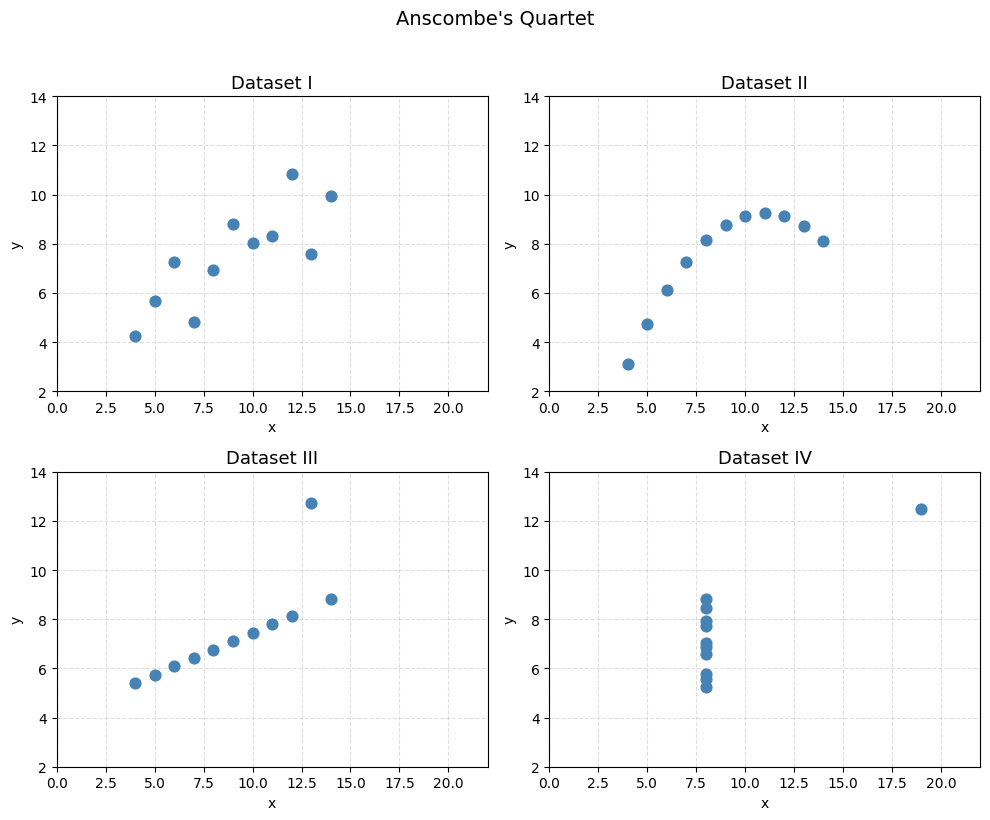

In [4]:
datasets = df['dataset'].unique()
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, name in zip(axes, datasets):
    grp = df[df['dataset'] == name]
    x, y = grp['x'].values, grp['y'].values

    ax.scatter(x, y, color='steelblue', s=60, zorder=3)
    ax.set_title(f'Dataset {name}', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 22)
    ax.set_ylim(2, 14)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle("Anscombe's Quartet", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot1_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Plot 2 — Summary Statistics Bar Chart

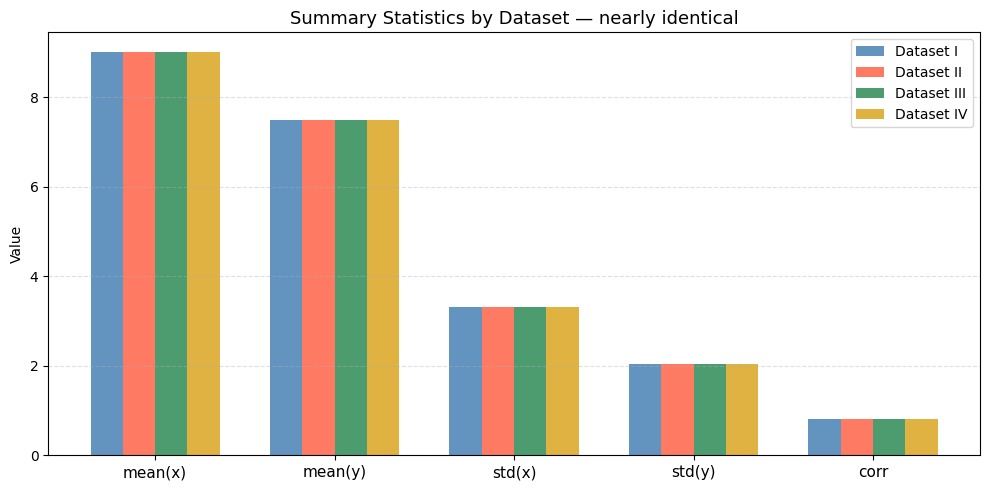

In [5]:
metrics = ['mean(x)', 'mean(y)', 'std(x)', 'std(y)', 'corr']
x_pos = np.arange(len(metrics))
width = 0.18
colors = ['steelblue', 'tomato', 'seagreen', 'goldenrod']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, row) in enumerate(stats_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x_pos + i * width, vals, width, label=f'Dataset {name}', color=colors[i], alpha=0.85)

ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Value')
ax.set_title('Summary Statistics by Dataset — nearly identical', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot2_stats_bars.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Plot 3 — Residual Plots

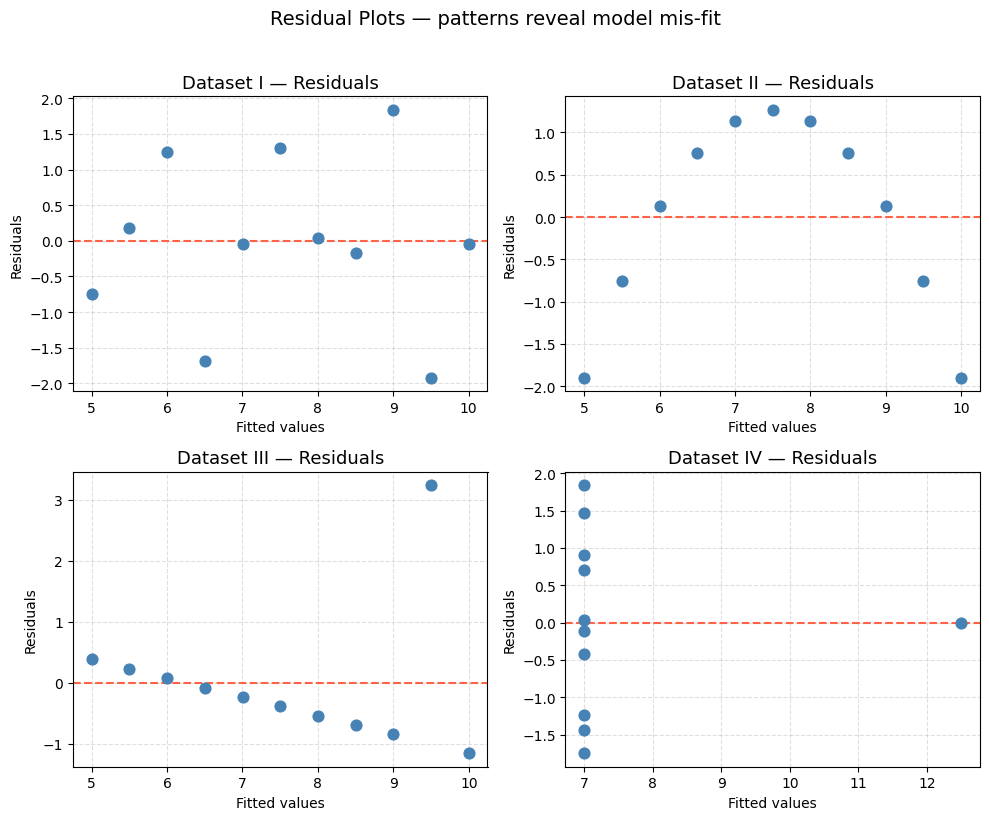

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, name in zip(axes, datasets):
    grp = df[df['dataset'] == name]
    x, y = grp['x'].values, grp['y'].values
    slope, intercept, *_ = stats.linregress(x, y)
    fitted = slope * x + intercept
    residuals = y - fitted

    ax.scatter(fitted, residuals, color='steelblue', s=60, zorder=3)
    ax.axhline(0, color='tomato', linewidth=1.5, linestyle='--')
    ax.set_title(f'Dataset {name} — Residuals', fontsize=13)
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Residual Plots — patterns reveal model mis-fit', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot3_residuals.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Conclusion

| Dataset | Pattern |
|---------|--------|
| I | Linear relationship with random scatter — the textbook case |
| II | Clean quadratic curve — a linear model is the wrong choice |
| III | Mostly linear, but one outlier pulls the regression line |
| IV | All x=8 except one leverage point (x=19) — that single point determines the slope |

**Key lesson**: summary statistics alone are insufficient. Always visualize your data.